# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [1]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Model Selection & Validation
# =====================================================
from sklearn.model_selection import PredefinedSplit, GridSearchCV


# 3. Pipeline Construction
# =====================================================
from sklearn.pipeline import Pipeline


# 4. Model Evaluation
# =====================================================
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)


# 5. Machine Learning Model
# =====================================================
from xgboost import XGBRegressor


# 6. Model Explainability
# =====================================================
import shap


# 7. Data Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns


# 8. Path Configuration
# =====================================================
import os
import joblib


# 9. Utilities
# =====================================================
import warnings

warnings.filterwarnings('ignore')






# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")
FINAL_DATA = os.path.join(DATA, "05_Final_Data")

EDA = os.path.join(PROJECT_ROOT, "03_EDA")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "04_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "05_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "06_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")

FINAL_SCORES = os.path.join(PROJECT_ROOT, "07_Final_ESG_Scores")
FINAL_SCORES_EXCEL = os.path.join(FINAL_SCORES, "01_Excel")
FINAL_SCORES_FIG = os.path.join(FINAL_SCORES, "02_Figures")

# <span style="color:#e0bda8">3. Reading the Data</span>

In [3]:
df_env_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_env_ml.csv')) 
df_env_ml = df_env_ml.set_index(['Economy', 'Year'])

df_soc_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_soc_ml.csv')) 
df_soc_ml = df_soc_ml.set_index(['Economy', 'Year'])

df_gov_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_gov_ml.csv')) 
df_gov_ml = df_gov_ml.set_index(['Economy', 'Year'])


df_env_raw = pd.read_csv(os.path.join(DATA_RAW, 'df_env_raw.csv')) 
df_env_raw = df_env_raw.set_index(['Economy', 'Year']).sort_index()

df_soc_raw = pd.read_csv(os.path.join(DATA_RAW, 'df_soc_raw.csv')) 
df_soc_raw = df_soc_raw.set_index(['Economy', 'Year']).sort_index()


df_gov_raw = pd.read_csv(os.path.join(DATA_RAW, 'df_gov_raw.csv')) 
df_gov_raw = df_gov_raw.set_index(['Economy', 'Year']).sort_index()

# <span style="color:#e0bda8">5. Model Training </span>

### <span style="color:#e0bda8">5.0. Auxiliary Functions </span>

In [4]:
def train_xgb_pipeline(df, target_col='Score', val_year=2018, test_year=2019,
                        random_state=42, pillar_png=None):
    """
    Trains an XGBoost model using a two-phase temporal pipeline.

    Phase 1 — Hyperparameter tuning:
        GridSearchCV with year-based blocked CV (PredefinedSplit) on the training
        set (years < val_year). Each fold uses all prior years as train and one
        single year as validation, respecting panel structure and chronological
        order. n_estimators is excluded here and determined in Phase 2.

    Phase 2 — Final training with early stopping:
        Retrains with the best hyperparameters from Phase 1. Early stopping is
        monitored on the validation set (val_year) to find optimal n_estimators.

    Temporal split:
        - Training:   years < val_year   (structural learning)
        - Validation: val_year           (early stopping only)
        - Test:       test_year          (out-of-sample evaluation)
        - 2020:       reserved for COVID stress test
    """

    # --- preserve original MultiIndex before reset ---
    original_index = df.index.copy()

    if isinstance(df.index, pd.MultiIndex) or any(
            name is not None for name in (df.index.names or [])):
        df = df.reset_index()

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    # --- identify year column (case-insensitive) ---
    year_col = next((c for c in df.columns if c.lower() == 'year'), None)
    if year_col is None:
        raise ValueError("Column 'Year' not found in DataFrame.")

    # --- remove identifier columns before modelling ---
    id_cols = [c for c in df.columns
               if c.lower() in ('economy', 'year', 'country', 'index')]
    if id_cols:
        print(f"Removing identifying columns: {id_cols}")

    X     = df.drop(columns=[target_col] + id_cols)
    y     = df[target_col].astype(float)
    years = df[year_col].values

    # --- check for remaining non-numeric columns ---
    non_numeric = [c for c in X.columns
                   if not pd.api.types.is_numeric_dtype(X[c])]
    if non_numeric:
        sample_vals = {c: X[c].dropna().unique()[:5].tolist()
                       for c in non_numeric}
        raise ValueError(
            f"Non-numeric predictor columns found: {non_numeric}. "
            f"Sample values: {sample_vals}"
        )

    # --- temporal masks ---
    train_mask  = years < val_year
    val_mask    = years == val_year
    test_mask   = years == test_year
    stress_mask = years == 2020

    X_train,  y_train  = X[train_mask].copy(),  y[train_mask].copy()
    X_val,    y_val    = X[val_mask].copy(),    y[val_mask].copy()
    X_test,   y_test   = X[test_mask].copy(),   y[test_mask].copy()
    X_stress, y_stress = X[stress_mask].copy(), y[stress_mask].copy()

    # --- restore original MultiIndex (Economy, Year) on all subsets ---
    X_train.index  = original_index[train_mask]
    y_train.index  = original_index[train_mask]
    X_val.index    = original_index[val_mask]
    y_val.index    = original_index[val_mask]
    X_test.index   = original_index[test_mask]
    y_test.index   = original_index[test_mask]
    X_stress.index = original_index[stress_mask]
    y_stress.index = original_index[stress_mask]

    print(f"Train: {train_mask.sum()} obs | Val: {val_mask.sum()} obs | "
          f"Test: {test_mask.sum()} obs | Stress (2020): {stress_mask.sum()} obs")

    # =========================================================
    # PHASE 1 — Year-blocked CV via PredefinedSplit
    #
    # Rationale: TimeSeriesSplit splits by row position, which for panel data
    # (N countries × T years) cuts mid-year when N×T is not evenly divisible
    # by (n_splits + 1). PredefinedSplit receives an explicit fold_id per row,
    # guaranteeing that every country-year in the same calendar year lands in
    # the same fold. Fold ids:
    #   -1  → always train (never used as validation)
    #    k  → validation in fold k (train = all rows with year < val_years_cv[k])
    #
    # Expanding window: each fold's training set grows by one year.
    # =========================================================

    train_years_arr = years[train_mask]
    unique_train_years = sorted(np.unique(train_years_arr))

    if len(unique_train_years) < 2:
        raise ValueError(
            f"At least 2 training years required for CV. Found: {unique_train_years}"
        )

    # validation years = all training years except the first
    # (the first year has no prior year to train on, so it can only be train)
    val_years_cv = unique_train_years[1:]

    # assign fold ids: -1 for the anchor year, k for each subsequent year
    fold_ids = np.full(len(X_train), -1, dtype=int)
    for k, yr in enumerate(val_years_cv):
        fold_ids[train_years_arr == yr] = k

    print(f"\nBlocked CV — {len(val_years_cv)} folds (expanding window):")
    for k, yr in enumerate(val_years_cv):
        n_tr  = (train_years_arr < yr).sum()
        n_val = (train_years_arr == yr).sum()
        print(f"  Fold {k}: train < {yr} ({n_tr} obs) | val = {yr} ({n_val} obs)")

    ps = PredefinedSplit(test_fold=fold_ids)

    pipe = Pipeline([('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=random_state,
        n_jobs=-1,
        n_estimators=300        # placeholder; refined by early stopping in Phase 2
    ))])

    param_grid = {
        'model__max_depth':        [3, 6],
        'model__learning_rate':    [0.01, 0.1],
        'model__subsample':        [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
        'model__reg_alpha':        [0, 0.1],
        'model__reg_lambda':       [1, 5],
    }

    grid = GridSearchCV(
        pipe, param_grid, cv=ps,
        scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=0, return_train_score=True
    )
    grid.fit(X_train.values, y_train.values)

    best_params = grid.best_params_
    print("\nBest hyperparameters (Phase 1):", best_params)

    cvres = pd.DataFrame(grid.cv_results_)
    cvres['rmse'] = np.sqrt(-cvres['mean_test_score'])
    display(cvres.sort_values('rank_test_score')[
        ['params', 'rmse', 'mean_train_score', 'std_test_score']
    ].head(10))

    # =========================================================
    # PHASE 2 — Retrain with best hyperparameters + early stopping
    #
    # val_year is used exclusively for early stopping; it is never
    # seen during Phase 1 hyperparameter search.
    # =========================================================

    final_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=random_state,
        n_jobs=-1,
        n_estimators=1000,          # upper bound; early stopping finds the optimum
        early_stopping_rounds=50,
        eval_metric='rmse',
        max_depth=        best_params['model__max_depth'],
        learning_rate=    best_params['model__learning_rate'],
        subsample=        best_params['model__subsample'],
        colsample_bytree= best_params['model__colsample_bytree'],
        reg_alpha=        best_params['model__reg_alpha'],
        reg_lambda=       best_params['model__reg_lambda'],
    )

    final_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    print(f"Optimal n_estimators (early stopping): {final_model.best_iteration}")

    # --- structural test set (test_year) ---
    y_pred = final_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"\n[Structural test {test_year}] RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    # --- COVID stress test (2020) ---
    y_stress_pred = final_model.predict(X_stress)
    rmse_s = root_mean_squared_error(y_stress, y_stress_pred)
    mae_s  = mean_absolute_error(y_stress, y_stress_pred)
    r2_s   = r2_score(y_stress, y_stress_pred)
    print(f"[Stress test 2020]     RMSE: {rmse_s:.4f} | MAE: {mae_s:.4f} | R²: {r2_s:.4f}")

    # --- SHAP on structural test set ---
    explainer   = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)

    # --- SHAP on COVID stress set ---
    shap_stress = explainer.shap_values(X_stress)

    # --- save SHAP feature importance ---
    shap_importance = pd.DataFrame({
        'feature':       X_test.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    shap_importance.to_csv(
        os.path.join(ML_SHAP_EXCEL, f'{pillar_png}_shap_importance.csv'),
        index=False
    )

    return {
        'best_params':    best_params,
        'final_model':    final_model,
        'metrics':        {'rmse': rmse,   'mae': mae,   'r2': r2},
        'metrics_stress': {'rmse': rmse_s, 'mae': mae_s, 'r2': r2_s},
        'X_train':        X_train,
        'X_val':          X_val,
        'X_test':         X_test,
        'X_stress':       X_stress,
        'y_test':         y_test,
        'y_stress':       y_stress,
        'y_pred':         y_pred,
        'y_stress_pred':  y_stress_pred,
        'test_index':     y_test.index,
        'shap_values':    shap_values,
        'shap_stress':    shap_stress,
        'explainer':      explainer,
    }

In [5]:
def show_const_vs_pred(results, pillar_png=None, pillar_title=None, include_stress=True):
    """
    Compare constructed vs predicted ESG scores for structural (2019) and stress (2020) tests.
    Displays error tables, generates scatter plots, and saves prediction outputs to CSV.
    
    """
    
    # --- structural test (2019) ---
    y_test = results['y_test']
    y_pred = pd.Series(results['y_pred'], index=y_test.index)

    pred_df = pd.DataFrame({
        'constructed': y_test,
        'predicted':   y_pred
    })
    pred_df['error']     = pred_df['predicted'] - pred_df['constructed']
    pred_df['abs_error'] = pred_df['error'].abs()

    print('\n--- Structural Test (2019) ---')
    print('\nLowest absolute errors:')
    display(pred_df.sort_values('abs_error', ascending=True).head(10))
    print('\nHighest absolute errors:')
    display(pred_df.sort_values('abs_error', ascending=False).head(10))

    # --- stress test (2020) ---
    has_stress = include_stress and 'y_stress_pred' in results and 'y_stress' in results

    if has_stress:
        y_stress      = results['y_stress']
        y_stress_pred = pd.Series(results['y_stress_pred'], index=y_stress.index)

        stress_df = pd.DataFrame({
            'constructed': y_stress,
            'predicted':   y_stress_pred
        })
        stress_df['error']     = stress_df['predicted'] - stress_df['constructed']
        stress_df['abs_error'] = stress_df['error'].abs()

        print('\n--- COVID Stress Test (2020) ---')
        print('\nLowest absolute errors:')
        display(stress_df.sort_values('abs_error', ascending=True).head(10))
        print('\nHighest absolute errors:')
        display(stress_df.sort_values('abs_error', ascending=False).head(10))

    # --- scatter plots ---
    ncols = 2 if has_stress else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
    if ncols == 1:
        axes = [axes]

    # 2019 scatter
    ax = axes[0]
    ax.scatter(pred_df['constructed'], pred_df['predicted'], alpha=0.6, color='#2C3E50')
    mn = min(pred_df['constructed'].min(), pred_df['predicted'].min())
    mx = max(pred_df['constructed'].max(), pred_df['predicted'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
    ax.set_xlabel('Constructed Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f'Constructed vs. Predicted Scores — Structural Test (2019), {pillar_title} Pillar')

    # 2020 scatter
    if has_stress:
        ax2 = axes[1]
        ax2.scatter(stress_df['constructed'], stress_df['predicted'], alpha=0.6, color='#C0392B')
        mn2 = min(stress_df['constructed'].min(), stress_df['predicted'].min())
        mx2 = max(stress_df['constructed'].max(), stress_df['predicted'].max())
        ax2.plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=1)
        ax2.set_xlabel('Constructed Score')
        ax2.set_ylabel('Predicted Score')
        ax2.set_title(f'Constructed vs. Predicted Scores — COVID-19 Stress Test (2020), {pillar_title} Pillar')

    plt.tight_layout()
    plt.savefig(os.path.join(ML_SHAP_FIG, f'{pillar_png}_constructed_vs_predicted.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # --- save 2019 predictions ---
    pred_df = pred_df.sort_index()
    pred_df.to_csv(os.path.join(ML_PRED, f"{pillar_png}_predictions_2019.csv"))

    # --- save 2020 predictions ---
    if has_stress:
        stress_df = stress_df.sort_index()
        stress_df.to_csv(os.path.join(ML_PRED, f"{pillar_png}_predictions_2020.csv"))
        return pred_df, stress_df
    else:
        return pred_df, None

## <span style="color:#e0bda8">5.1. Environmental Pillar </span>

In [6]:
env_model = train_xgb_pipeline(df_env_ml, pillar_png='env')

Removing identifying columns: ['Economy', 'Year']
Train: 222 obs | Val: 37 obs | Test: 37 obs | Stress (2020): 37 obs

Blocked CV — 5 folds (expanding window):
  Fold 0: train < 2013 (37 obs) | val = 2013 (37 obs)
  Fold 1: train < 2014 (74 obs) | val = 2014 (37 obs)
  Fold 2: train < 2015 (111 obs) | val = 2015 (37 obs)
  Fold 3: train < 2016 (148 obs) | val = 2016 (37 obs)
  Fold 4: train < 2017 (185 obs) | val = 2017 (37 obs)

Best hyperparameters (Phase 1): {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}


,params,rmse,mean_train_score,std_test_score
22,"{'model__colsample_bytree': 0.8, 'model__learn...",1.262230,-0.007377,0.599752
18,"{'model__colsample_bytree': 0.8, 'model__learn...",1.279684,-0.006411,0.593520
16,"{'model__colsample_bytree': 0.8, 'model__learn...",1.320597,-0.001829,0.684904
20,"{'model__colsample_bytree': 0.8, 'model__learn...",1.327091,-0.002301,0.780442
52,"{'model__colsample_bytree': 1.0, 'model__learn...",1.355837,-0.001992,0.574731
21,"{'model__colsample_bytree': 0.8, 'model__learn...",1.368740,-0.002463,0.787940
48,"{'model__colsample_bytree': 1.0, 'model__learn...",1.373305,-0.001615,0.626525
54,"{'model__colsample_bytree': 1.0, 'model__learn...",1.385653,-0.006955,0.636826
50,"{'model__colsample_bytree': 1.0, 'model__learn...",1.389005,-0.005947,0.637980
19,"{'model__colsample_bytree': 0.8, 'model__learn...",1.412092,-0.009047,0.684978


Optimal n_estimators (early stopping): 770

[Structural test 2019] RMSE: 1.5180 | MAE: 1.1207 | R²: 0.9451
[Stress test 2020]     RMSE: 1.9311 | MAE: 1.6038 | R²: 0.9029


In [7]:
joblib.dump(env_model['final_model'], os.path.join(ML_MODELS, "env_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese Explore\\06_ML_Results\\03_Models\\env_model.pkl']


--- Structural Test (2019) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Armenia,2019,47.525080,47.507172,-0.017908,0.017908
Netherlands,2019,50.368781,50.339493,-0.029289,0.029289
Sweden,2019,67.403693,67.308212,-0.095480,0.095480
Greece,2019,54.304346,54.160984,-0.143362,0.143362
Switzerland,2019,62.221835,62.377434,0.155599,0.155599
Belgium,2019,50.099589,50.301407,0.201818,0.201818
Iceland,2019,66.626453,66.397781,-0.228671,0.228671
Finland,2019,60.662660,61.018578,0.355918,0.355918
Norway,2019,66.959401,66.590004,-0.369397,0.369397



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Czechia,2019,44.705820,48.759735,4.053915,4.053915
Portugal,2019,59.397798,55.686966,-3.710832,3.710832
Romania,2019,59.067622,55.736256,-3.331367,3.331367
Denmark,2019,59.700920,56.769497,-2.931423,2.931423
North Macedonia,2019,50.099641,52.612274,2.512633,2.512633
Slovenia,2019,60.672562,58.598888,-2.073674,2.073674
Germany,2019,49.722607,51.610069,1.887462,1.887462
Albania,2019,65.620679,63.915886,-1.704793,1.704793
Ukraine,2019,47.078091,48.694099,1.616009,1.616009



--- COVID Stress Test (2020) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Serbia,2020,50.579407,50.588341,0.008934,0.008934
Switzerland,2020,61.589877,61.560249,-0.029628,0.029628
Italy,2020,55.476858,55.215420,-0.261438,0.261438
Montenegro,2020,60.235134,59.812046,-0.423087,0.423087
Iceland,2020,65.679509,65.122726,-0.556783,0.556783
Norway,2020,67.209913,66.623772,-0.586141,0.586141
Lithuania,2020,65.279694,65.867630,0.587936,0.587936
Greece,2020,54.323575,53.709282,-0.614293,0.614293
Croatia,2020,63.535482,62.911137,-0.624346,0.624346



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Czechia,2020,47.311425,51.346401,4.034976,4.034976
France,2020,59.035495,55.071342,-3.964153,3.964153
Denmark,2020,59.727367,56.078426,-3.648941,3.648941
Romania,2020,60.289980,57.122429,-3.167551,3.167551
Bosnia and Herzegovina,2020,57.290913,54.336060,-2.954853,2.954853
Ireland,2020,57.583309,60.510025,2.926716,2.926716
Latvia,2020,69.301170,66.742569,-2.558601,2.558601
Albania,2020,65.762199,63.203705,-2.558494,2.558494
Hungary,2020,54.336474,51.850147,-2.486326,2.486326


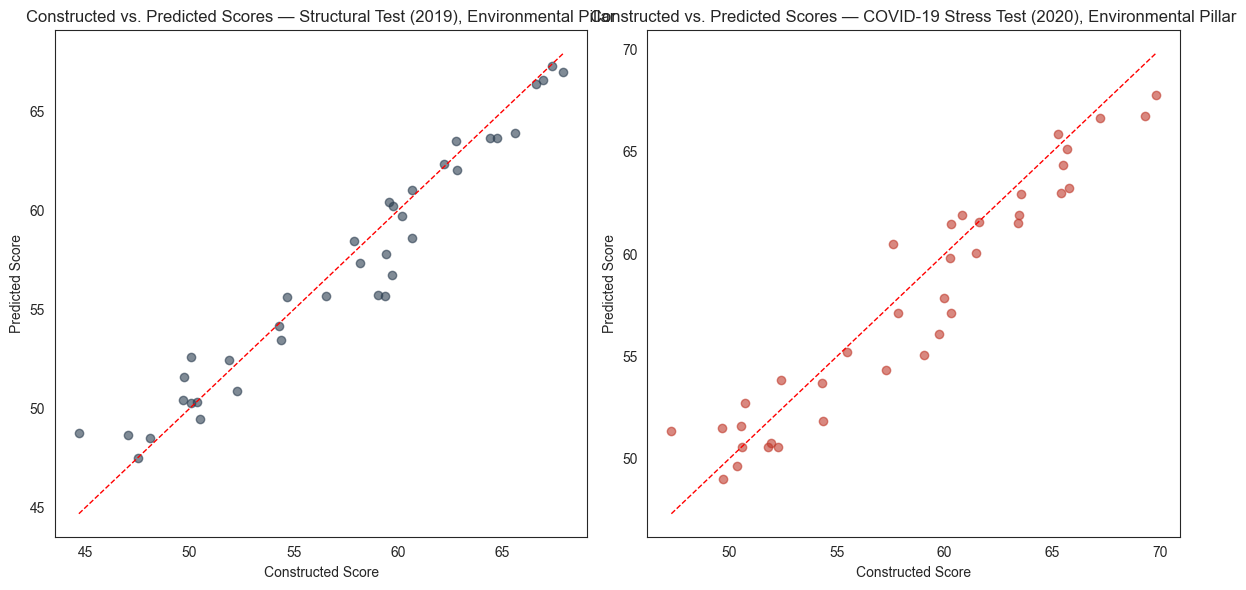

In [27]:
df_env_predictions, df_env_stress = show_const_vs_pred(env_model, pillar_png='env', pillar_title='Environmental')

## <span style="color:#e0bda8">5.2. Social Pillar </span>

In [9]:
soc_model = train_xgb_pipeline(df_soc_ml, pillar_png='soc')

Removing identifying columns: ['Economy', 'Year']
Train: 222 obs | Val: 37 obs | Test: 37 obs | Stress (2020): 37 obs

Blocked CV — 5 folds (expanding window):
  Fold 0: train < 2013 (37 obs) | val = 2013 (37 obs)
  Fold 1: train < 2014 (74 obs) | val = 2014 (37 obs)
  Fold 2: train < 2015 (111 obs) | val = 2015 (37 obs)
  Fold 3: train < 2016 (148 obs) | val = 2016 (37 obs)
  Fold 4: train < 2017 (185 obs) | val = 2017 (37 obs)

Best hyperparameters (Phase 1): {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}


,params,rmse,mean_train_score,std_test_score
48,"{'model__colsample_bytree': 1.0, 'model__learn...",1.112412,-5.153120e-03,0.405694
50,"{'model__colsample_bytree': 1.0, 'model__learn...",1.119424,-1.238822e-02,0.652460
28,"{'model__colsample_bytree': 0.8, 'model__learn...",1.123311,-1.508165e-04,0.315262
18,"{'model__colsample_bytree': 0.8, 'model__learn...",1.126105,-1.225194e-02,0.481908
16,"{'model__colsample_bytree': 0.8, 'model__learn...",1.130148,-5.262821e-03,0.398114
52,"{'model__colsample_bytree': 1.0, 'model__learn...",1.132071,-5.827579e-03,0.429721
20,"{'model__colsample_bytree': 0.8, 'model__learn...",1.133359,-5.674548e-03,0.411984
54,"{'model__colsample_bytree': 1.0, 'model__learn...",1.141724,-1.464509e-02,0.606813
22,"{'model__colsample_bytree': 0.8, 'model__learn...",1.149018,-1.397381e-02,0.506303
24,"{'model__colsample_bytree': 0.8, 'model__learn...",1.158554,-8.629741e-07,0.293436


Optimal n_estimators (early stopping): 290

[Structural test 2019] RMSE: 2.2069 | MAE: 1.4757 | R²: 0.9740
[Stress test 2020]     RMSE: 2.5350 | MAE: 1.7743 | R²: 0.9647


In [10]:
joblib.dump(soc_model['final_model'], os.path.join(ML_MODELS, "soc_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese Explore\\06_ML_Results\\03_Models\\soc_model.pkl']


--- Structural Test (2019) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Spain,2019,66.501775,66.561256,0.059481,0.059481
Switzerland,2019,81.062838,81.140038,0.077199,0.077199
Portugal,2019,70.909917,70.821381,-0.088536,0.088536
Denmark,2019,79.563679,79.468948,-0.094731,0.094731
Sweden,2019,79.931866,79.799629,-0.132237,0.132237
Germany,2019,80.520663,80.347366,-0.173297,0.173297
Bulgaria,2019,61.536833,61.330662,-0.206171,0.206171
Austria,2019,77.996242,77.753380,-0.242862,0.242862
Belgium,2019,78.400775,77.977303,-0.423473,0.423473



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
North Macedonia,2019,37.916884,45.378429,7.461545,7.461545
Serbia,2019,44.734571,50.481098,5.746527,5.746527
Albania,2019,40.982092,46.403790,5.421697,5.421697
Bosnia and Herzegovina,2019,39.333308,42.048309,2.715002,2.715002
United Kingdom,2019,71.769046,74.389175,2.620129,2.620129
Slovak Republic,2019,71.072910,68.538124,-2.534786,2.534786
Latvia,2019,68.589578,66.134438,-2.455141,2.455141
Armenia,2019,36.109962,33.784855,-2.325108,2.325108
Moldova,2019,52.475951,50.510433,-1.965518,1.965518



--- COVID Stress Test (2020) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Slovenia,2020,78.552528,78.660973,0.108445,0.108445
Sweden,2020,78.613792,78.733704,0.119912,0.119912
Czechia,2020,79.161784,78.932655,-0.229129,0.229129
Belgium,2020,77.377012,77.135757,-0.241255,0.241255
Denmark,2020,79.631404,79.372597,-0.258807,0.258807
Portugal,2020,67.828973,67.518745,-0.310227,0.310227
Netherlands,2020,79.823539,80.196587,0.373047,0.373047
Ireland,2020,71.608719,72.066841,0.458122,0.458122
Slovak Republic,2020,70.266327,69.798958,-0.467369,0.467369



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Albania,2020,38.201731,45.784363,7.582632,7.582632
North Macedonia,2020,37.353064,44.139675,6.786611,6.786611
Serbia,2020,44.940498,50.190247,5.249748,5.249748
Armenia,2020,38.163437,34.146935,-4.016503,4.016503
Lithuania,2020,67.633661,71.518013,3.884352,3.884352
Italy,2020,61.583348,65.306969,3.723620,3.723620
Bosnia and Herzegovina,2020,38.777085,42.325745,3.548659,3.548659
United Kingdom,2020,70.690083,74.000168,3.310085,3.310085
Finland,2020,76.793502,79.275665,2.482163,2.482163


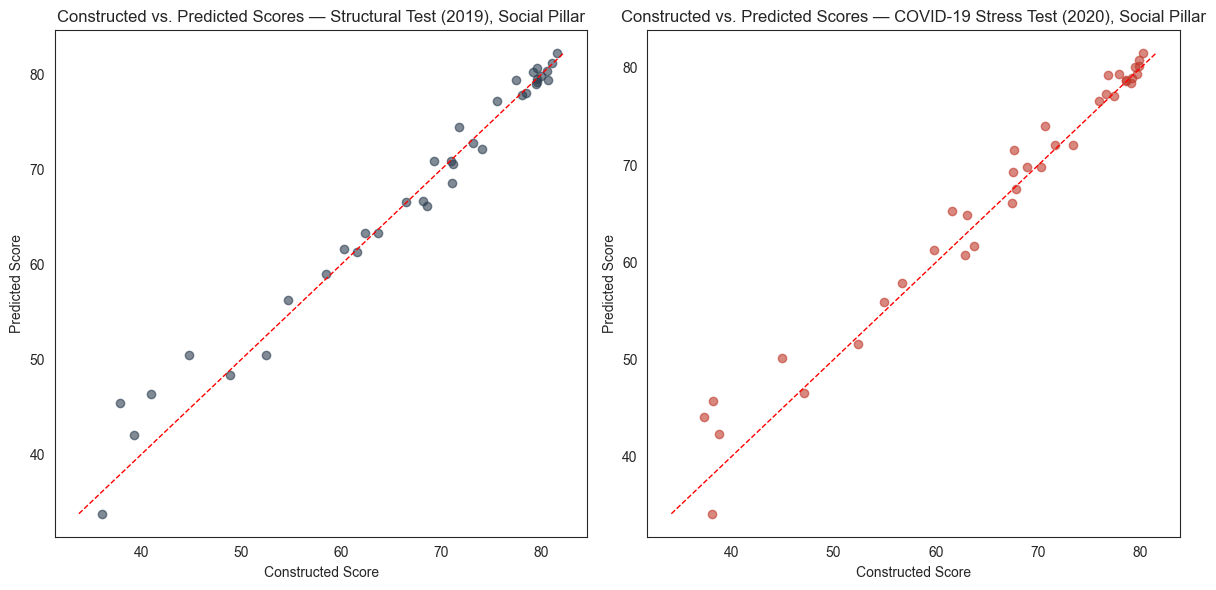

In [26]:
df_soc_predictions, df_soc_stress = show_const_vs_pred(soc_model, pillar_png='soc', pillar_title='Social')

## <span style="color:#e0bda8">5.3. Governance Pillar </span>

In [12]:
gov_model = train_xgb_pipeline(df_gov_ml, target_col='Score', pillar_png='gov')

Removing identifying columns: ['Economy', 'Year']
Train: 222 obs | Val: 37 obs | Test: 37 obs | Stress (2020): 37 obs

Blocked CV — 5 folds (expanding window):
  Fold 0: train < 2013 (37 obs) | val = 2013 (37 obs)
  Fold 1: train < 2014 (74 obs) | val = 2014 (37 obs)
  Fold 2: train < 2015 (111 obs) | val = 2015 (37 obs)
  Fold 3: train < 2016 (148 obs) | val = 2016 (37 obs)
  Fold 4: train < 2017 (185 obs) | val = 2017 (37 obs)



Best hyperparameters (Phase 1): {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__reg_alpha': 0.1, 'model__reg_lambda': 1, 'model__subsample': 0.8}


,params,rmse,mean_train_score,std_test_score
52,"{'model__colsample_bytree': 1.0, 'model__learn...",1.700438,-0.009232,1.234539
16,"{'model__colsample_bytree': 0.8, 'model__learn...",1.709282,-0.009489,1.021879
20,"{'model__colsample_bytree': 0.8, 'model__learn...",1.722687,-0.011066,1.136826
48,"{'model__colsample_bytree': 1.0, 'model__learn...",1.727327,-0.008123,1.345250
21,"{'model__colsample_bytree': 0.8, 'model__learn...",1.781876,-0.011303,1.328056
17,"{'model__colsample_bytree': 0.8, 'model__learn...",1.801393,-0.013280,1.321886
22,"{'model__colsample_bytree': 0.8, 'model__learn...",1.808410,-0.026454,1.277764
54,"{'model__colsample_bytree': 1.0, 'model__learn...",1.819380,-0.025239,1.204786
18,"{'model__colsample_bytree': 0.8, 'model__learn...",1.826180,-0.024284,1.313899
50,"{'model__colsample_bytree': 1.0, 'model__learn...",1.840580,-0.022383,1.201157


Optimal n_estimators (early stopping): 998

[Structural test 2019] RMSE: 2.5187 | MAE: 1.9115 | R²: 0.9818
[Stress test 2020]     RMSE: 2.8045 | MAE: 2.2638 | R²: 0.9776


In [13]:
joblib.dump(gov_model['final_model'], os.path.join(ML_MODELS, "gov_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese Explore\\06_ML_Results\\03_Models\\gov_model.pkl']


--- Structural Test (2019) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Germany,2019,80.235119,80.232185,-0.002934,0.002934
Slovenia,2019,63.435463,63.293110,-0.142353,0.142353
Spain,2019,67.057495,67.247269,0.189773,0.189773
Lithuania,2019,52.389889,52.122032,-0.267856,0.267856
Switzerland,2019,86.276598,85.846848,-0.429751,0.429751
Slovak Republic,2019,49.474647,49.907501,0.432854,0.432854
Romania,2019,35.194197,34.671741,-0.522455,0.522455
Denmark,2019,84.264715,83.723259,-0.541456,0.541456
Estonia,2019,63.823189,64.412460,0.589271,0.589271



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Iceland,2019,76.701652,70.021255,-6.680396,6.680396
Austria,2019,82.088680,75.971016,-6.117664,6.117664
Belgium,2019,77.819316,71.958565,-5.860751,5.860751
United Kingdom,2019,77.492964,73.642029,-3.850935,3.850935
Moldova,2019,25.541691,28.930855,3.389163,3.389163
Bulgaria,2019,36.524783,39.888115,3.363332,3.363332
North Macedonia,2019,39.124750,35.868256,-3.256495,3.256495
Ukraine,2019,32.994977,29.918779,-3.076197,3.076197
Poland,2019,55.742658,52.965771,-2.776887,2.776887



--- COVID Stress Test (2020) ---

Lowest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Slovenia,2020,64.151274,64.045471,-0.105803,0.105803
Greece,2020,51.785499,51.896893,0.111393,0.111393
Finland,2020,87.009882,86.885765,-0.124117,0.124117
Lithuania,2020,54.735861,54.894596,0.158735,0.158735
Croatia,2020,49.431724,49.127407,-0.304317,0.304317
Austria,2020,82.682617,82.359688,-0.322929,0.322929
Hungary,2020,49.663072,49.999928,0.336856,0.336856
Denmark,2020,84.107205,83.364311,-0.742894,0.742894
Romania,2020,35.928364,36.674393,0.746029,0.746029



Highest absolute errors:


,,constructed,predicted,error,abs_error
Economy,Year,,,,
Belgium,2020,78.626025,72.488533,-6.137492,6.137492
Bosnia and Herzegovina,2020,27.062963,32.346680,5.283717,5.283717
Spain,2020,67.043022,62.014984,-5.028038,5.028038
Luxembourg,2020,68.541510,63.818703,-4.722808,4.722808
Montenegro,2020,34.895632,30.490454,-4.405178,4.405178
North Macedonia,2020,41.173136,36.971420,-4.201716,4.201716
Ukraine,2020,33.835526,30.000675,-3.834851,3.834851
Moldova,2020,25.124550,28.866976,3.742426,3.742426
Ireland,2020,55.203632,58.856792,3.653161,3.653161


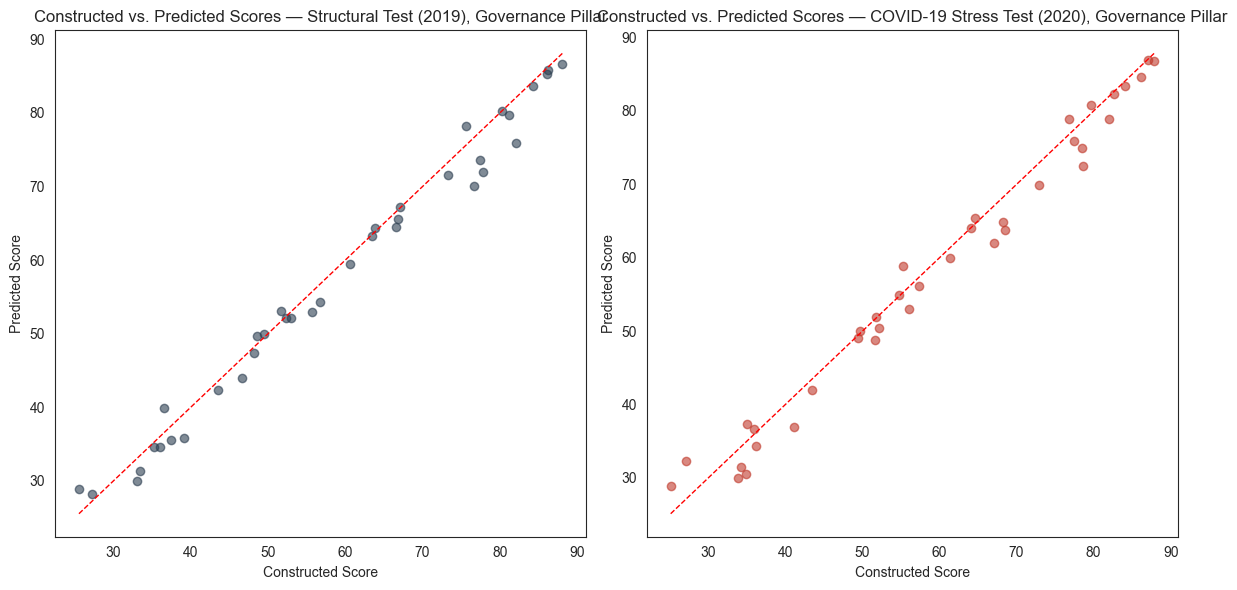

In [25]:
df_gov_predictions, df_gov_stress = show_const_vs_pred(gov_model, pillar_png='gov', pillar_title='Governance')

## <span style="color:#e0bda8">5.4. Metrics Table </span>

In [15]:
metrics_df = pd.DataFrame({
    'Environmental': {**env_model['metrics'], **{f'stress_{k}': v for k, v in env_model['metrics_stress'].items()}},
    'Social':        {**soc_model['metrics'], **{f'stress_{k}': v for k, v in soc_model['metrics_stress'].items()}},
    'Governance':    {**gov_model['metrics'], **{f'stress_{k}': v for k, v in gov_model['metrics_stress'].items()}}
}).T

metrics_df.columns = ['RMSE (2019)', 'MAE (2019)', 'R² (2019)', 'RMSE (2020)', 'MAE (2020)', 'R² (2020)']
metrics_df
metrics_df.to_excel(os.path.join(ML_METRICS, "ml_metrics.xlsx"))

In [16]:
metrics_df

,RMSE (2019),MAE (2019),R² (2019),RMSE (2020),MAE (2020),R² (2020)
Environmental,1.518032,1.120703,0.945106,1.931071,1.603843,0.902902
Social,2.206862,1.475669,0.974000,2.534955,1.774262,0.964749
Governance,2.518708,1.911475,0.981839,2.804516,2.263782,0.977562


# <span style="color:#e0bda8">6. SHAP Visualizations </span>

### <span style="color:#e0bda8">6.0. Auxiliary Functions </span>

In [28]:
def plot_shap(shap_values, X_test, pillar_png=None, pillar_title=None):
    """
    Generate SHAP visualizations (bar plot and beeswarm plot) for feature importance.
    Saves both plots as high-resolution images.
    """

    # --- BAR PLOT (global feature importance) ---
    sns.set_style("white")
    plt.rcParams["axes.grid"] = False

    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        max_display=40,
        show=False
    )

    # adjust figure size and title
    fig = plt.gcf()
    fig.set_size_inches(16, 8)
    plt.title(f"SHAP Feature Importance - {pillar_title} Pillar", fontsize=16)
    plt.tight_layout()

    # save bar plot
    plt.savefig(
        os.path.join(ML_SHAP_FIG, f'{pillar_png}_shap_barplot.png'),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # --- BEESWARM PLOT (distribution of SHAP values) ---
    shap.summary_plot(
        shap_values,
        X_test,
        max_display=40,
        show=False
    )

    # adjust figure size and title
    fig = plt.gcf()
    fig.set_size_inches(16, 8)
    plt.title(f"SHAP Value Distribution (Beeswarm) — {pillar_title} Pillar", fontsize=16)
    plt.tight_layout()

    # save beeswarm plot
    plt.savefig(
        os.path.join(ML_SHAP_FIG, f'{pillar_png}_shap_beeswarm.png'),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


In [18]:
def compare_shap_weights_stress(results, weights, pillar_png=None, pillar_title=None):
    """
    Compares theoretical weights with SHAP feature importance for both
    the structural test (2019) and the COVID stress test (2020).

    Outputs a unified bar plot with three components:
        - Statistical weights (theoretical importance)
        - SHAP importance (2019 baseline)
        - SHAP importance (2020 stress scenario)

    Also computes Pearson correlation between SHAP 2019 and SHAP 2020.
    """

    from scipy.stats import pearsonr

    # --- Compute SHAP importance (mean absolute values) ---
    shap_2019 = np.abs(results['shap_values']).mean(axis=0)
    shap_2020 = np.abs(results['shap_stress']).mean(axis=0)

    # --- Normalize SHAP values to sum to 1 (relative importance) ---
    shap_2019 = shap_2019 / shap_2019.sum()
    shap_2020 = shap_2020 / shap_2020.sum()

    # --- Extract feature names ---
    features = results['X_test'].columns

    # --- Align weights with feature order ---
    weights = weights.reindex(features)

    # --- Create combined DataFrame ---
    df = pd.DataFrame({
        'feature': features,
        'Weight': weights,
        'SHAP_2019': shap_2019,
        'SHAP_2020': shap_2020
    })

    # --- Sort by theoretical weights (structural hierarchy) ---
    df = df.sort_values('Weight', ascending=False)

    # --- Compute Pearson correlation between SHAP distributions ---
    corr1, pvalue1 = pearsonr(df['SHAP_2019'], df['SHAP_2020'])
    corr2, pvalue2 = pearsonr(df['SHAP_2019'], df['Weight'])
    corr3, pvalue3 = pearsonr(df['SHAP_2020'], df['Weight'])
    
    print(f"Pearson correlation (2019 vs 2020): {corr1:.4f} | p-value: {pvalue1:.4f}")
    print(f"Pearson correlation (2019 vs Weights): {corr2:.4f} | p-value: {pvalue2:.4f}")
    print(f"Pearson correlation (2020 vs Weights): {corr3:.4f} | p-value: {pvalue3:.4f}")
    
    # --- Reshape for plotting ---
    df_plot = df.melt(
        id_vars='feature',
        value_vars=['Weight', 'SHAP_2019', 'SHAP_2020'],
        var_name='Type',
        value_name='Importance'
    )

    # --- Plot configuration ---
    sns.set_style("white")
    plt.figure(figsize=(12, 10))

    palette = {
    'Weight': '#2C3E50',   
    'SHAP_2019': '#E67E22', 
    'SHAP_2020': '#C0392B'   
    }

    ax = sns.barplot(
        data=df_plot,
        y='feature',
        x='Importance',
        hue='Type',
        palette=palette,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9
    )

    # --- Clean visual style ---
    ax.set_facecolor("white")
    ax.grid(False)
    plt.gcf().patch.set_facecolor("white")

    # --- Titles and labels ---
    plt.title(
        f'Variance Weights vs. SHAP Feature Importance: Structural Test (2019) and Stress Test (2020) — {pillar_title} Pillar',
        fontsize=14,
        fontweight='bold',
        loc='left',
        pad=15
    )

    plt.xlabel('Relative Importance', fontsize=12, fontweight='bold')
    plt.ylabel('')

    # --- Legend ---
    plt.legend(
        title="Metric",
        title_fontsize=13,
        fontsize=11,
        loc='lower right',
        frameon=True,
        shadow=True
    )

    # --- Remove spines for cleaner look ---
    sns.despine(left=True, bottom=True)

    plt.tight_layout()

    # --- Save figure if path provided ---
    if pillar_png:
        plt.savefig(
            os.path.join(ML_SHAP_FIG, f'{pillar_png}_full_comparison.png'),
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    return df

## <span style="color:#e0bda8">6.1. Environmental Pillar </span>

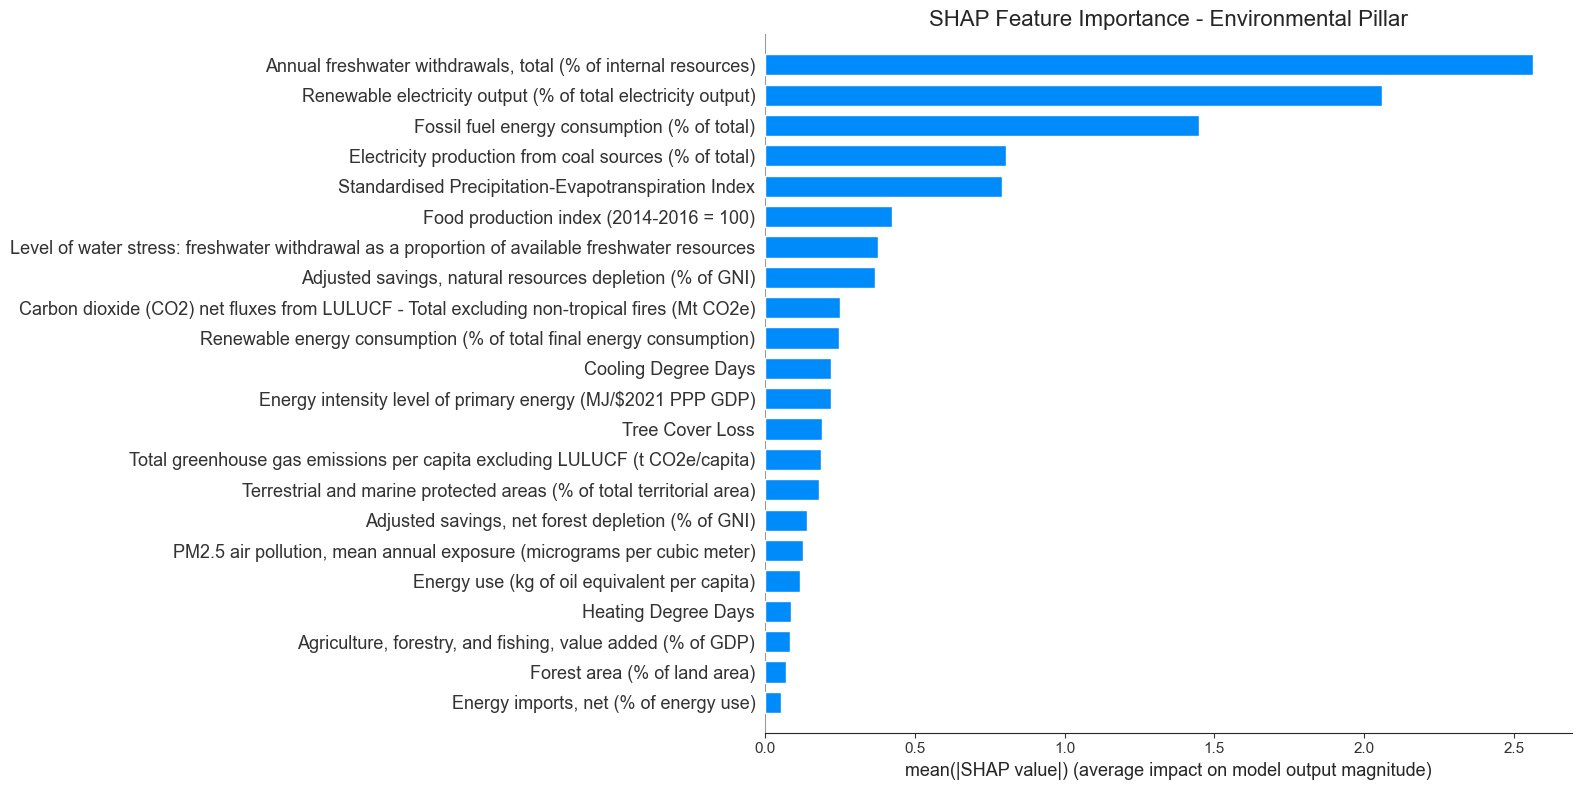

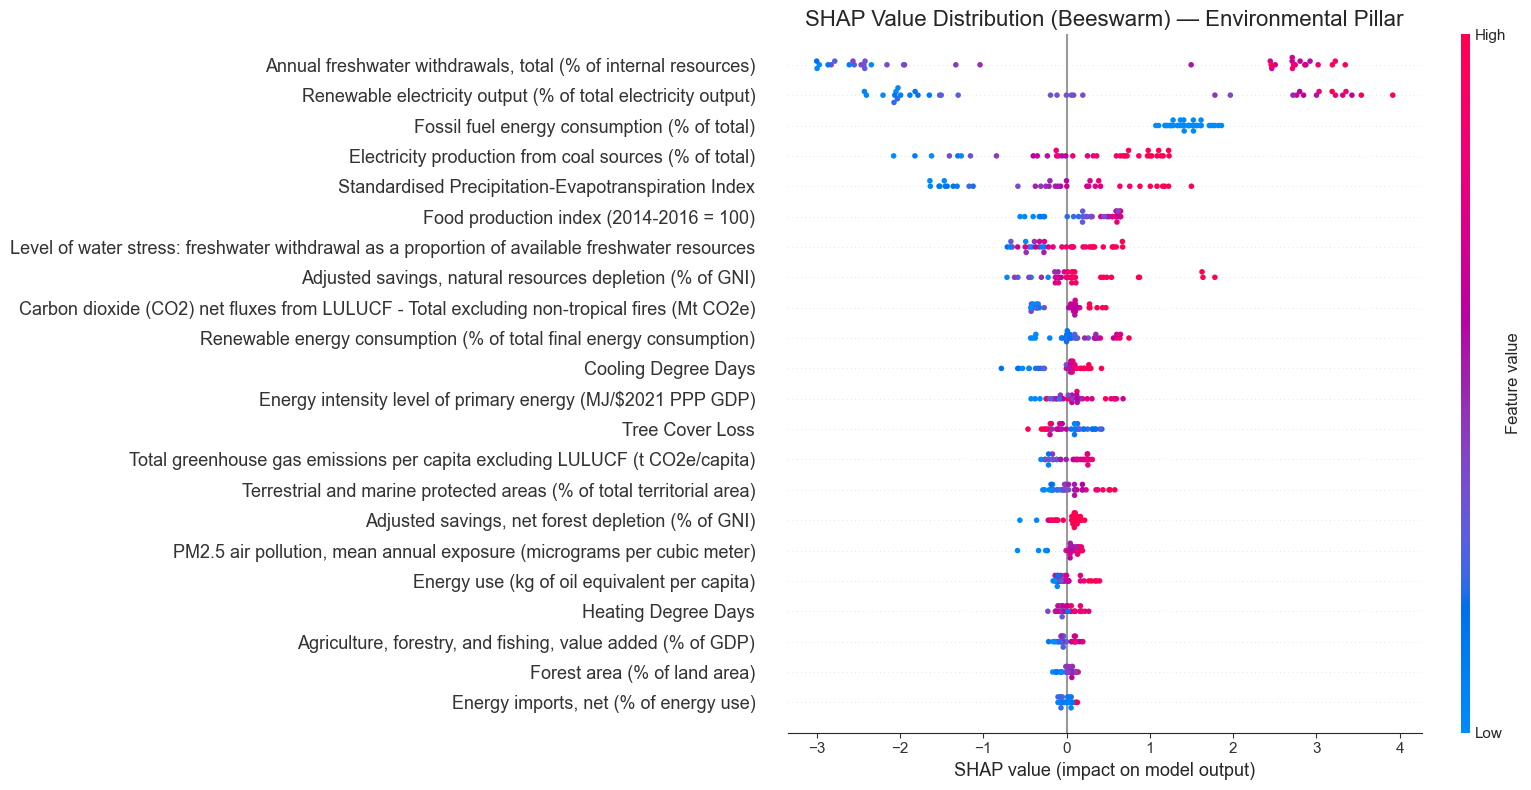

In [29]:
plot_shap(env_model['shap_values'], env_model['X_test'], pillar_png='env', pillar_title='Environmental')

Pearson correlation (2019 vs 2020): 0.9954 | p-value: 0.0000
Pearson correlation (2019 vs Weights): 0.5648 | p-value: 0.0062
Pearson correlation (2020 vs Weights): 0.5632 | p-value: 0.0064


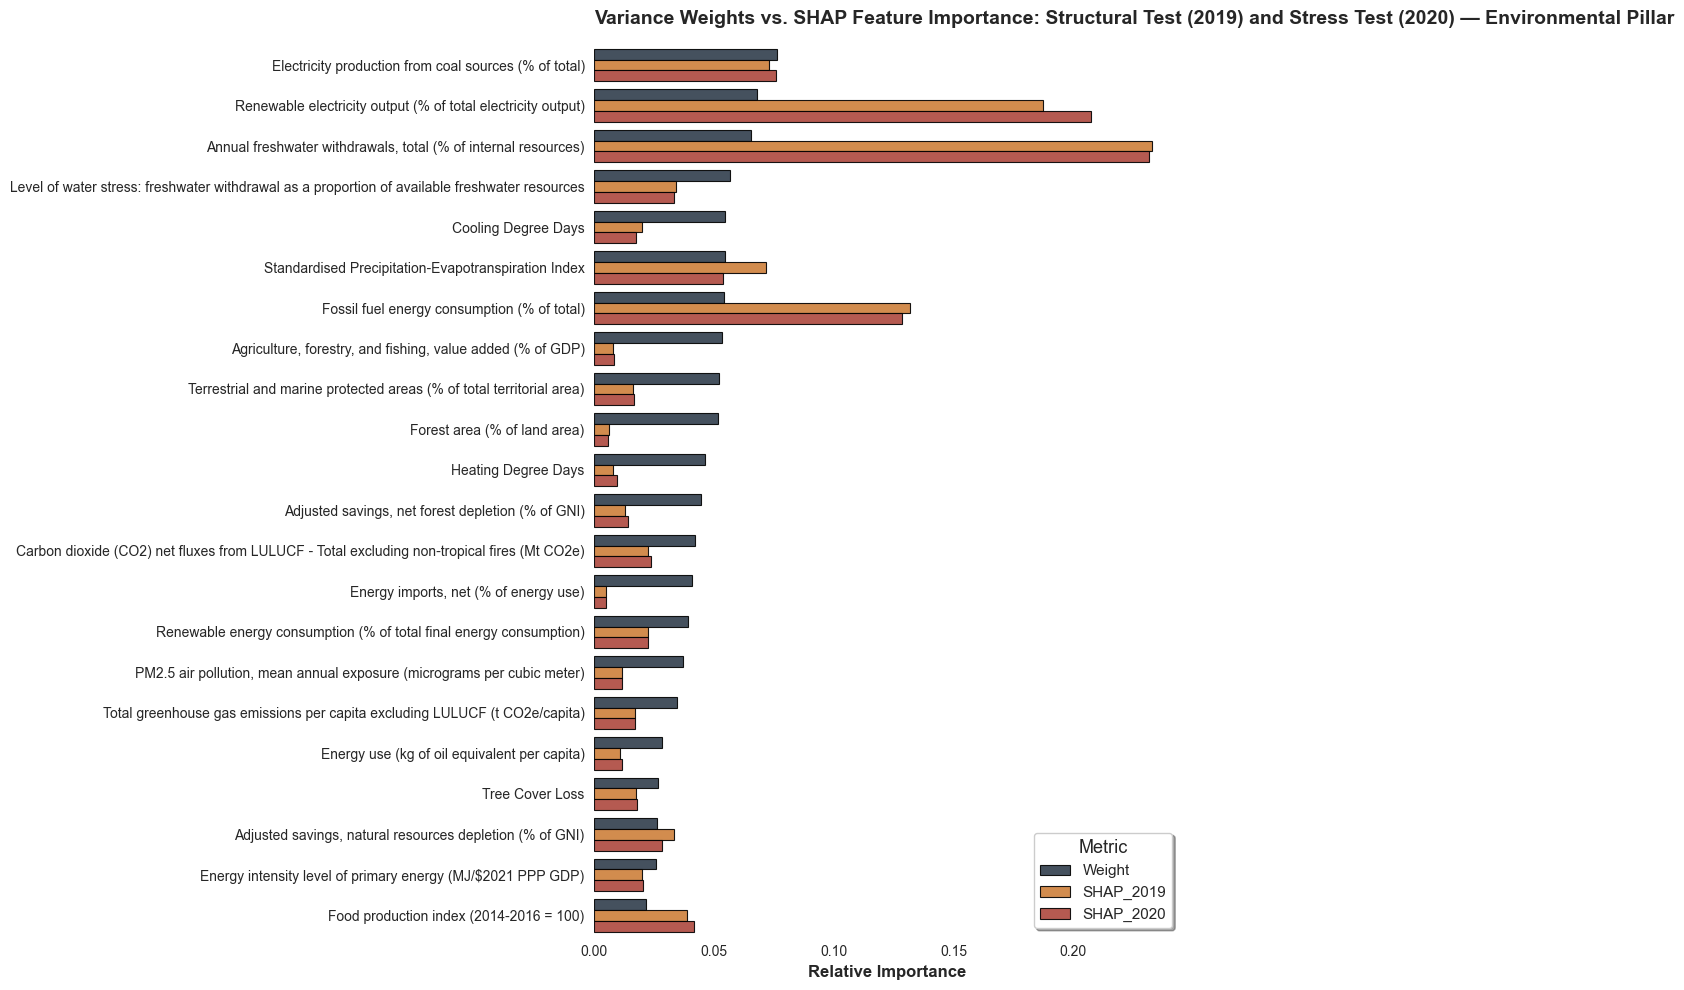

,feature,Weight,SHAP_2019,SHAP_2020
Electricity production from coal sources (% of total),Electricity production from coal sources (% of...,0.076092,0.073075,0.075811
Renewable electricity output (% of total electricity output),Renewable electricity output (% of total elect...,0.067889,0.187183,0.207474
"Annual freshwater withdrawals, total (% of internal resources)","Annual freshwater withdrawals, total (% of int...",0.065581,0.232954,0.231845
Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,Level of water stress: freshwater withdrawal a...,0.056722,0.034232,0.033198
Cooling Degree Days,Cooling Degree Days,0.054577,0.020094,0.017274
Standardised Precipitation-Evapotranspiration Index,Standardised Precipitation-Evapotranspiration ...,0.054504,0.071820,0.053634
Fossil fuel energy consumption (% of total),Fossil fuel energy consumption (% of total),0.054154,0.131668,0.128298
"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value adde...",0.053448,0.007724,0.008182
Terrestrial and marine protected areas (% of total territorial area),Terrestrial and marine protected areas (% of t...,0.051860,0.016234,0.016363
Forest area (% of land area),Forest area (% of land area),0.051525,0.006229,0.005736


In [20]:
X = df_env_ml.drop(columns=['Score'])

variances = X.var()
weights = variances / variances.sum()

compare_shap_weights_stress(
    env_model,
    weights,
    pillar_title="Environmental",
    pillar_png='env'
)

## <span style="color:#e0bda8">6.2. Social Pillar </span>

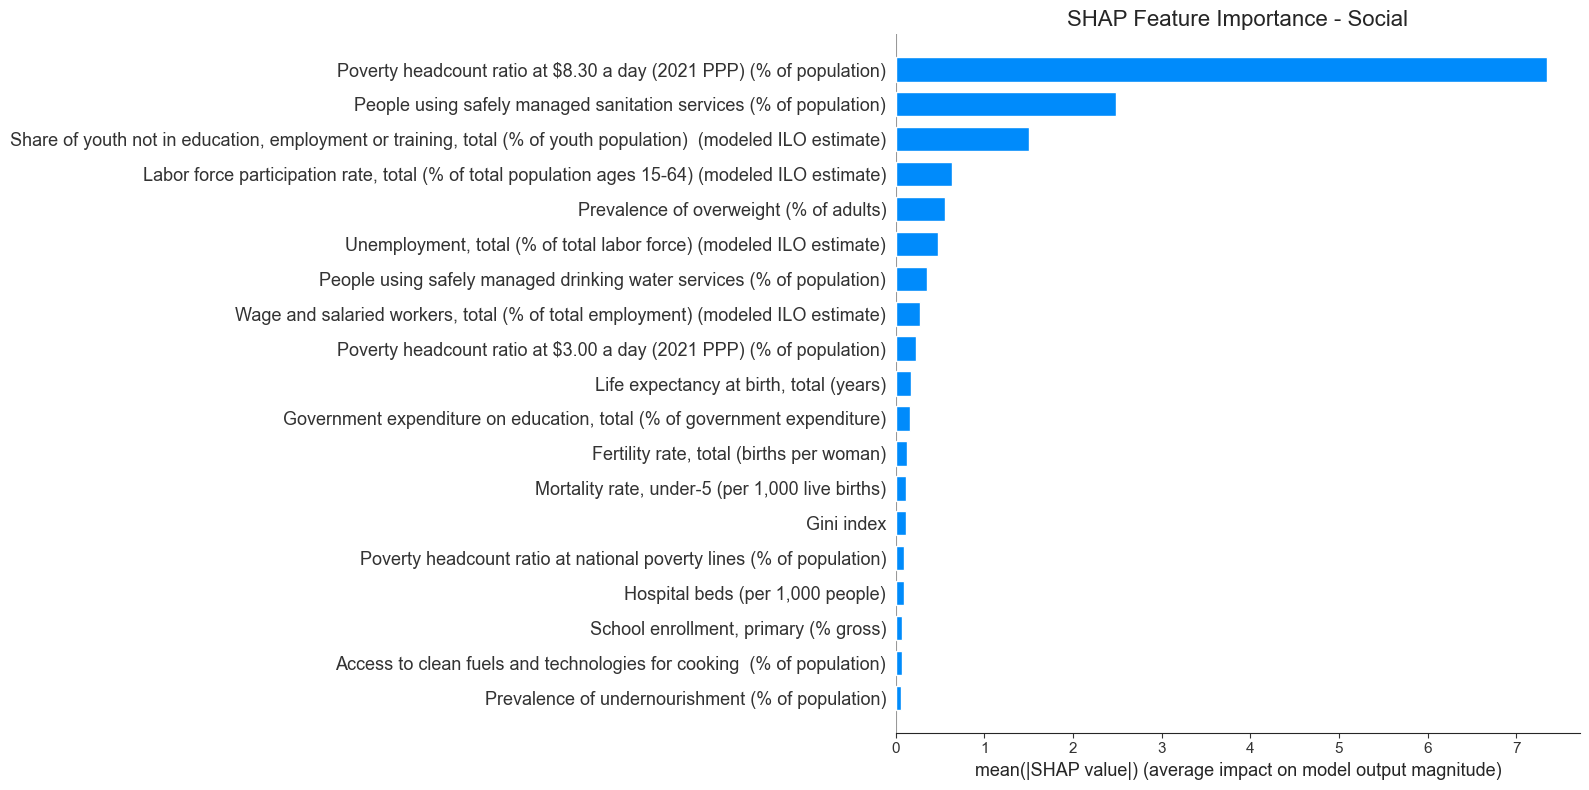

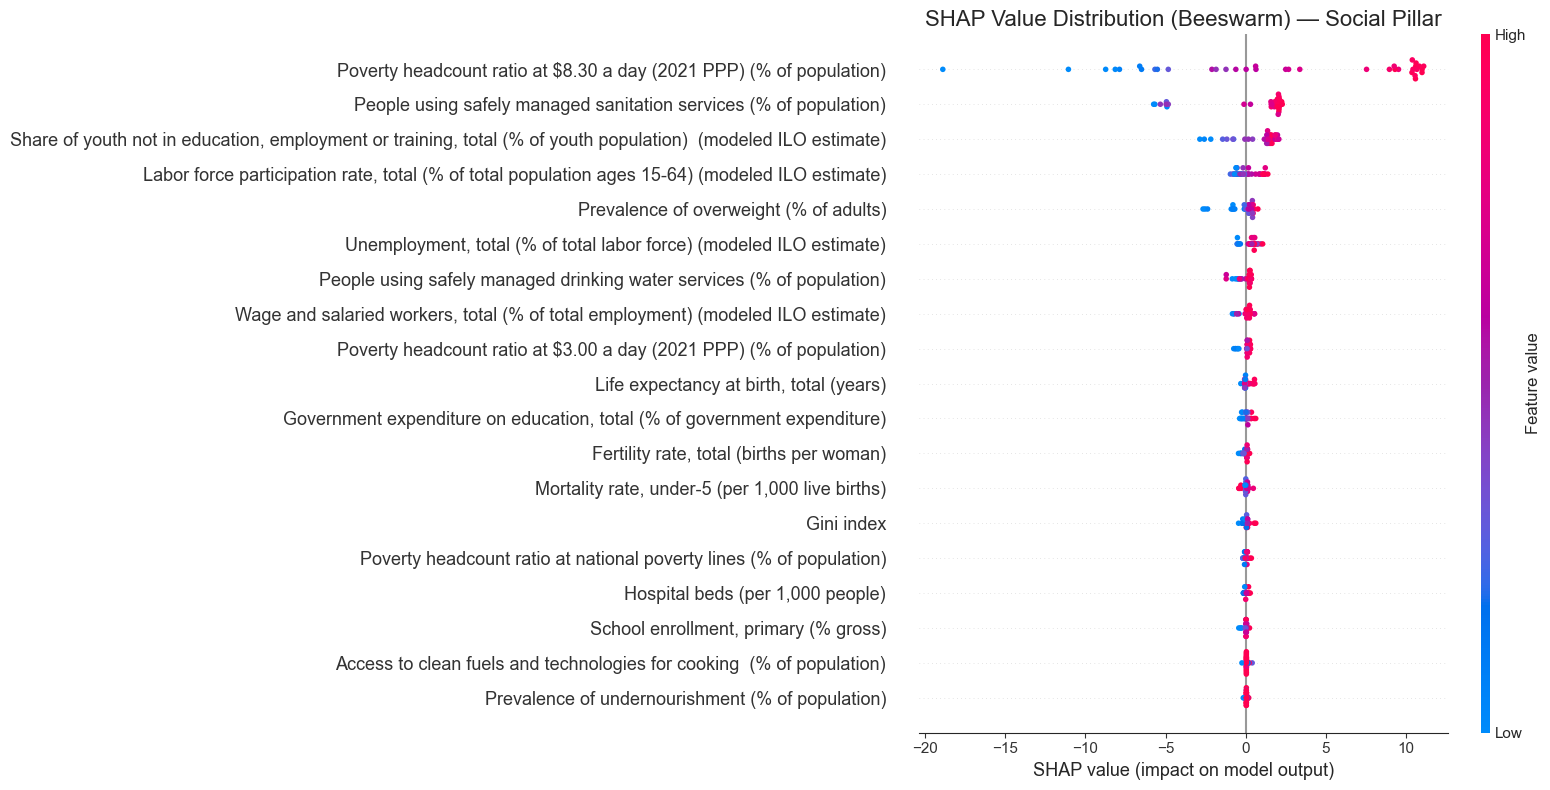

In [21]:
plot_shap(soc_model['shap_values'], soc_model['X_test'], pillar_png='soc', pillar_title='Social')

Pearson correlation (2019 vs 2020): 0.9999 | p-value: 0.0000
Pearson correlation (2019 vs Weights): 0.6178 | p-value: 0.0048
Pearson correlation (2020 vs Weights): 0.6144 | p-value: 0.0051


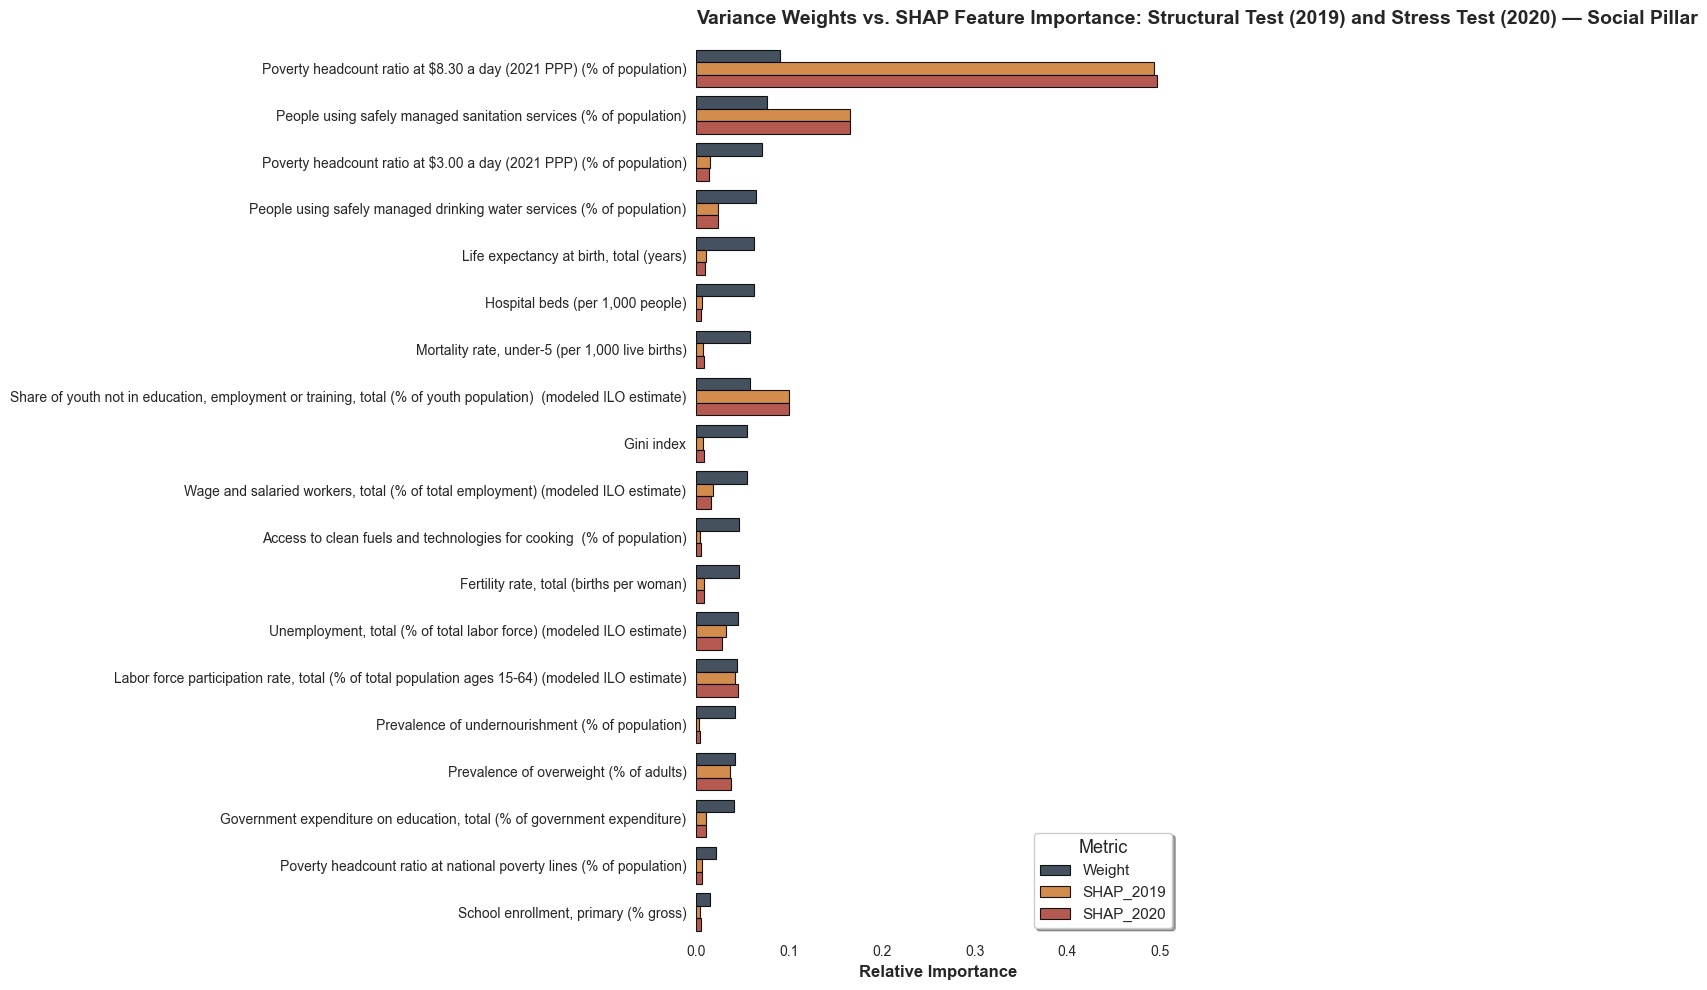

,feature,Weight,SHAP_2019,SHAP_2020
Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population),Poverty headcount ratio at $8.30 a day (2021 P...,0.090708,0.492866,0.496394
People using safely managed sanitation services (% of population),People using safely managed sanitation service...,0.076549,0.166378,0.165396
Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Poverty headcount ratio at $3.00 a day (2021 P...,0.071557,0.015541,0.014063
People using safely managed drinking water services (% of population),People using safely managed drinking water ser...,0.064938,0.023893,0.024137
"Life expectancy at birth, total (years)","Life expectancy at birth, total (years)",0.062974,0.011187,0.009380
"Hospital beds (per 1,000 people)","Hospital beds (per 1,000 people)",0.062132,0.006050,0.005900
"Mortality rate, under-5 (per 1,000 live births)","Mortality rate, under-5 (per 1,000 live births)",0.058430,0.008055,0.008277
"Share of youth not in education, employment or training, total (% of youth population) (modeled ILO estimate)","Share of youth not in education, employment or...",0.058191,0.100446,0.099651
Gini index,Gini index,0.055288,0.008046,0.008582
"Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total e...",0.054867,0.018027,0.016479


In [22]:
X = df_soc_ml.drop(columns=['Score'])

variances = X.var()
weights = variances / variances.sum()

compare_shap_weights_stress(
    soc_model,
    weights,
    pillar_title="Social",
    pillar_png='soc'
)

## <span style="color:#e0bda8">6.3. Governance Pillar </span>

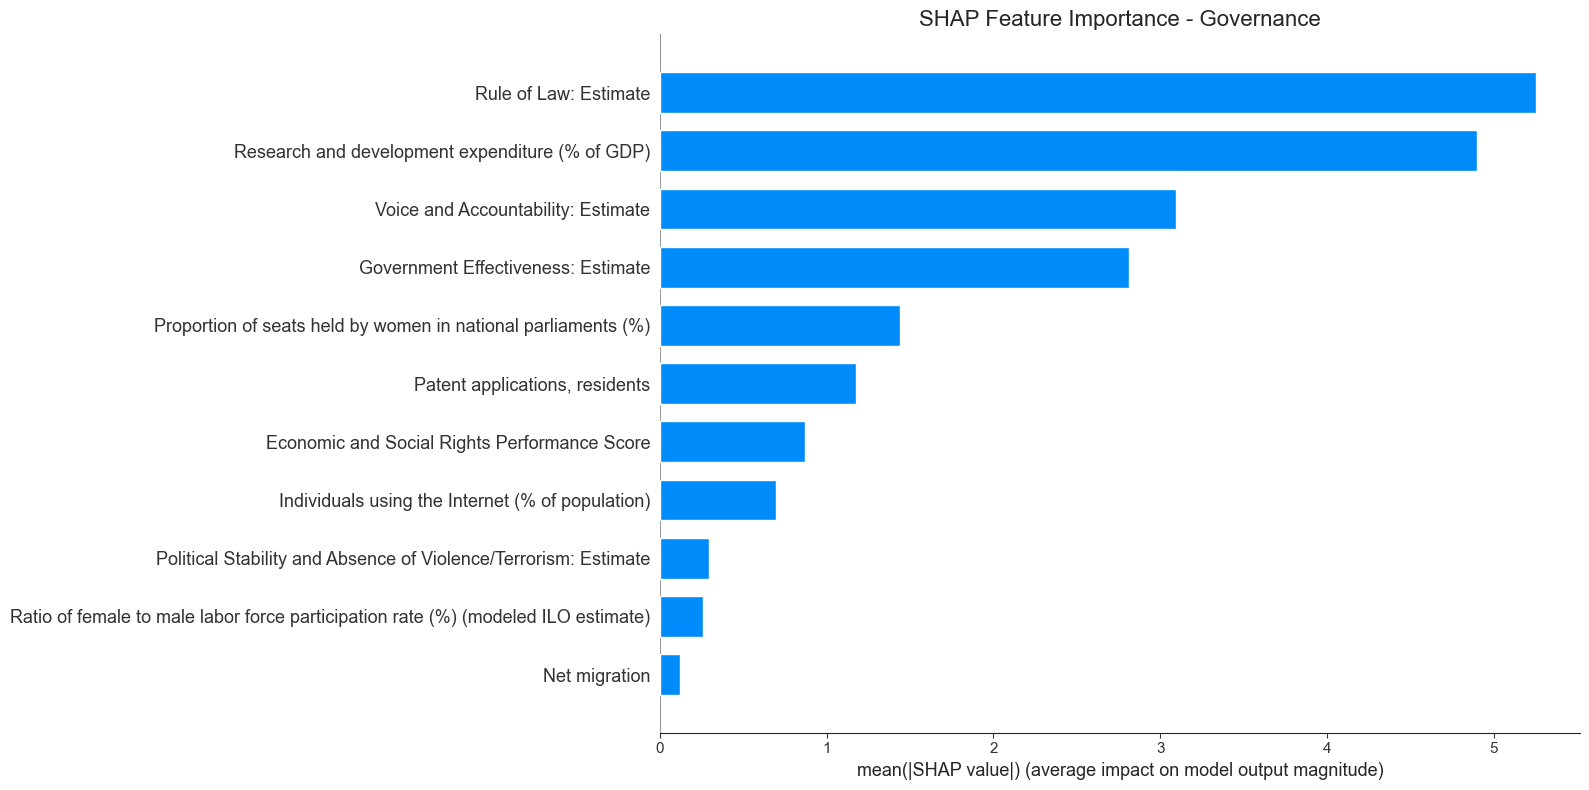

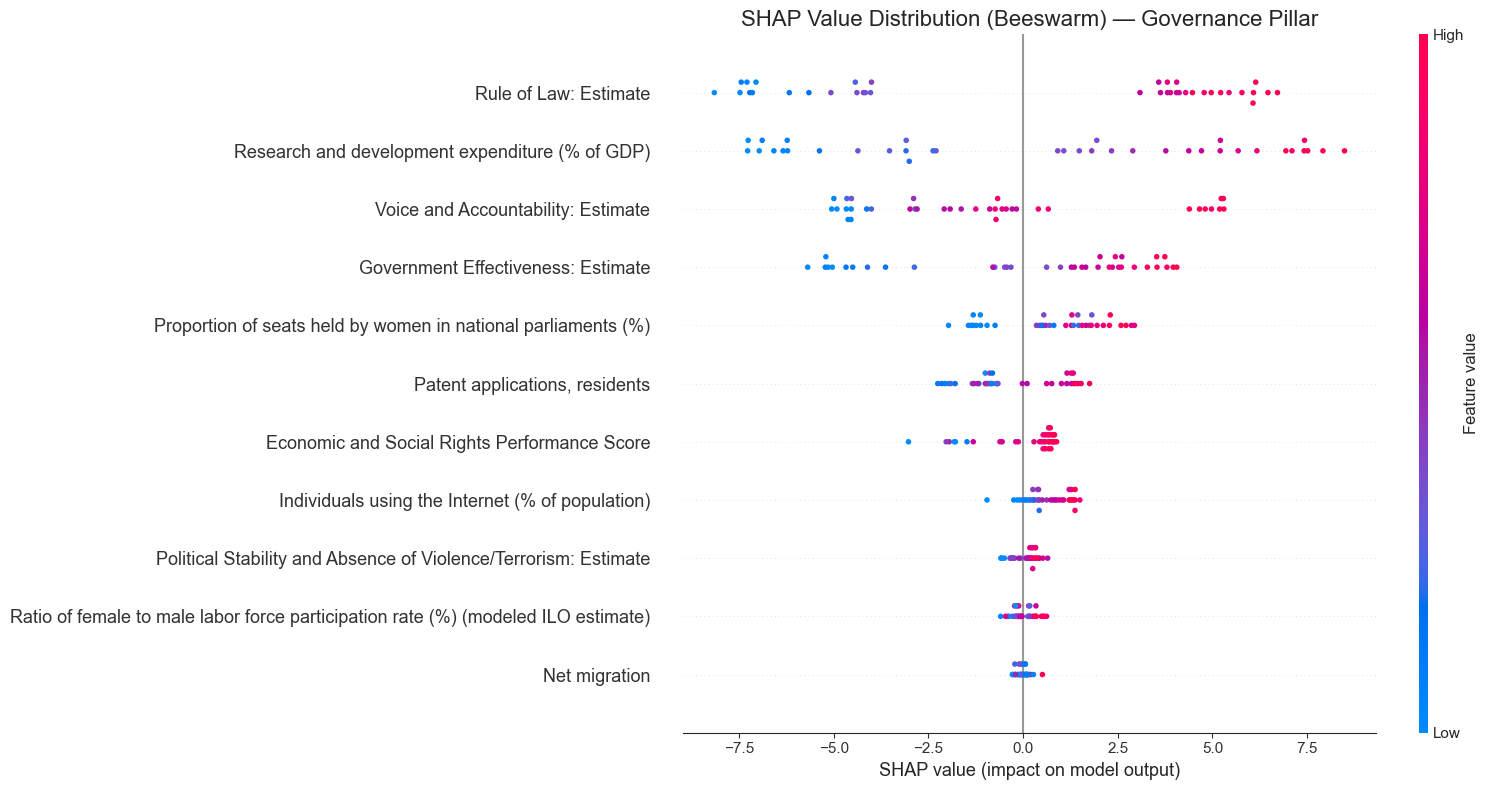

In [23]:
plot_shap(gov_model['shap_values'], gov_model['X_test'], pillar_png='gov', pillar_title='Governance')

Pearson correlation (2019 vs 2020): 0.9987 | p-value: 0.0000
Pearson correlation (2019 vs Weights): 0.8384 | p-value: 0.0013
Pearson correlation (2020 vs Weights): 0.8431 | p-value: 0.0011


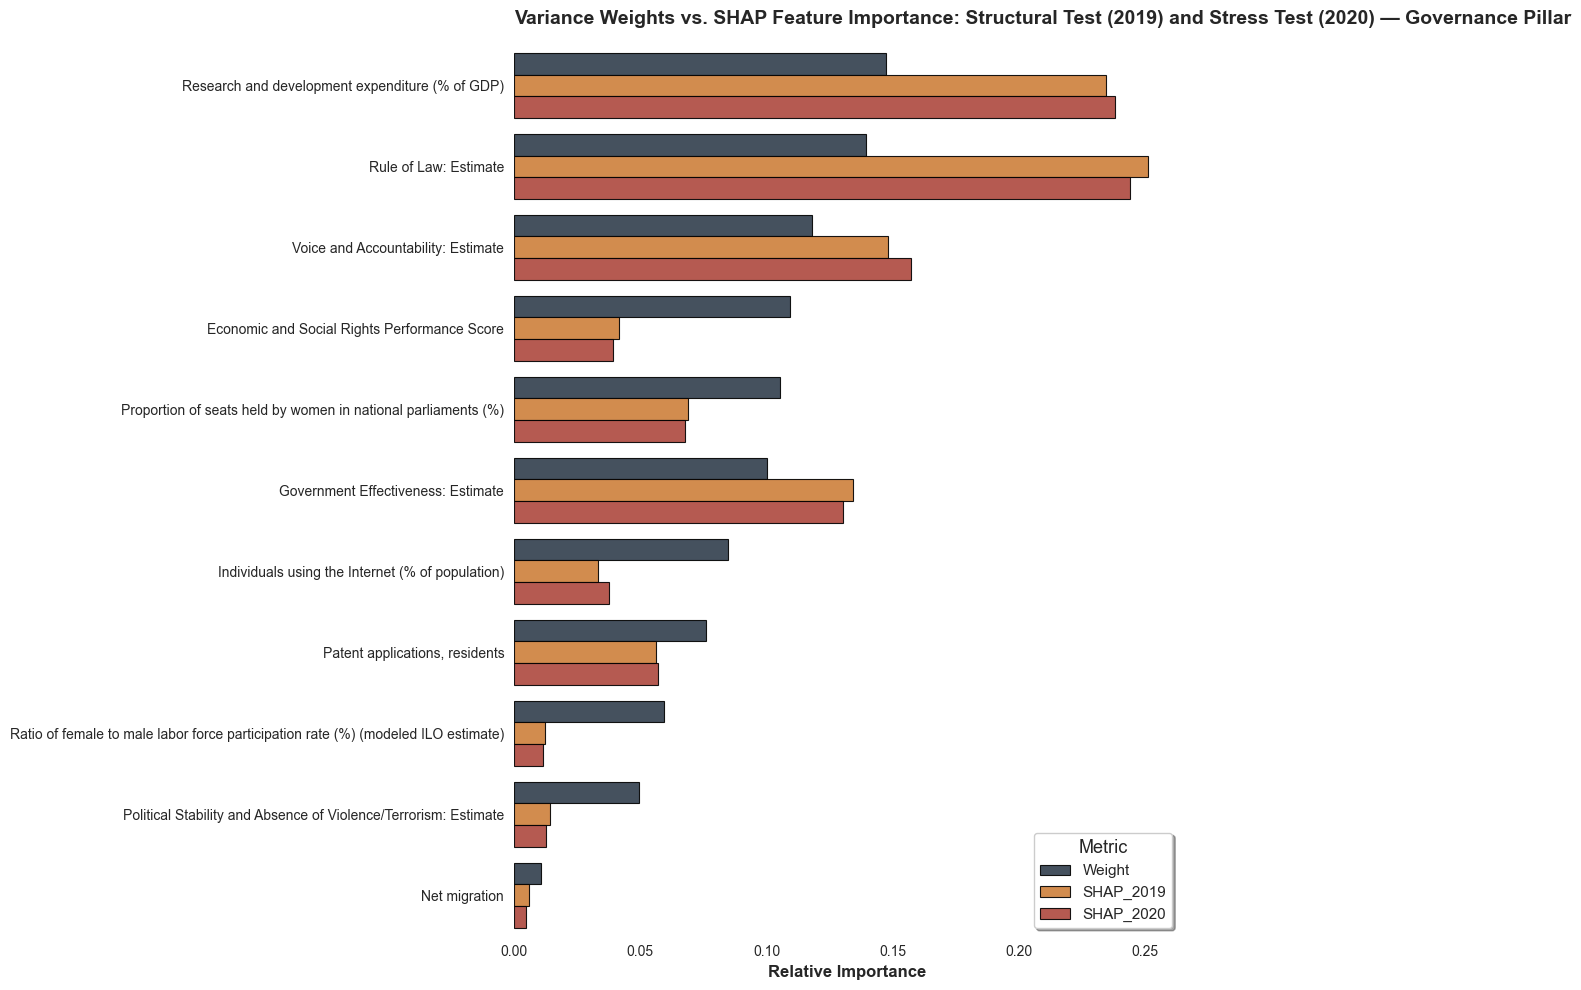

,feature,Weight,SHAP_2019,SHAP_2020
Research and development expenditure (% of GDP),Research and development expenditure (% of GDP),0.147325,0.234235,0.237892
Rule of Law: Estimate,Rule of Law: Estimate,0.139200,0.251171,0.243785
Voice and Accountability: Estimate,Voice and Accountability: Estimate,0.117855,0.147920,0.157341
Economic and Social Rights Performance Score,Economic and Social Rights Performance Score,0.109382,0.041599,0.039362
Proportion of seats held by women in national parliaments (%),Proportion of seats held by women in national ...,0.105365,0.068903,0.067712
Government Effectiveness: Estimate,Government Effectiveness: Estimate,0.100228,0.134335,0.130183
Individuals using the Internet (% of population),Individuals using the Internet (% of population),0.084849,0.033256,0.037596
"Patent applications, residents","Patent applications, residents",0.076214,0.056192,0.057062
Ratio of female to male labor force participation rate (%) (modeled ILO estimate),Ratio of female to male labor force participat...,0.059223,0.012472,0.011481
Political Stability and Absence of Violence/Terrorism: Estimate,Political Stability and Absence of Violence/Te...,0.049500,0.014088,0.012862


In [24]:
X = df_gov_ml.drop(columns=['Score'])

variances = X.var()
weights = variances / variances.sum()

compare_shap_weights_stress(
    gov_model,
    weights,
    pillar_title="Governance",
    pillar_png='gov'
)